## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('colorblind')

## 2. Dataset loading and EDA


Dataset Shape: (14204, 13)

Data Types:
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
source                           str
dtype: object

Missing Values Count:
Item_Weight          2439
Outlet_Size          4016
Item_Outlet_Sales    5681
dtype: int64

Duplicate Rows: 0

Numerical Features Summary:
        Item_Weight  Item_Visibility      Item_MRP  Outlet_Establishment_Year  \
count  11765.000000     14204.000000  14204.000000               14204.000000   
mean      12.792854         0.065953    141.004977                1997.830681   
std        4.652502         0.051459     62.086938          

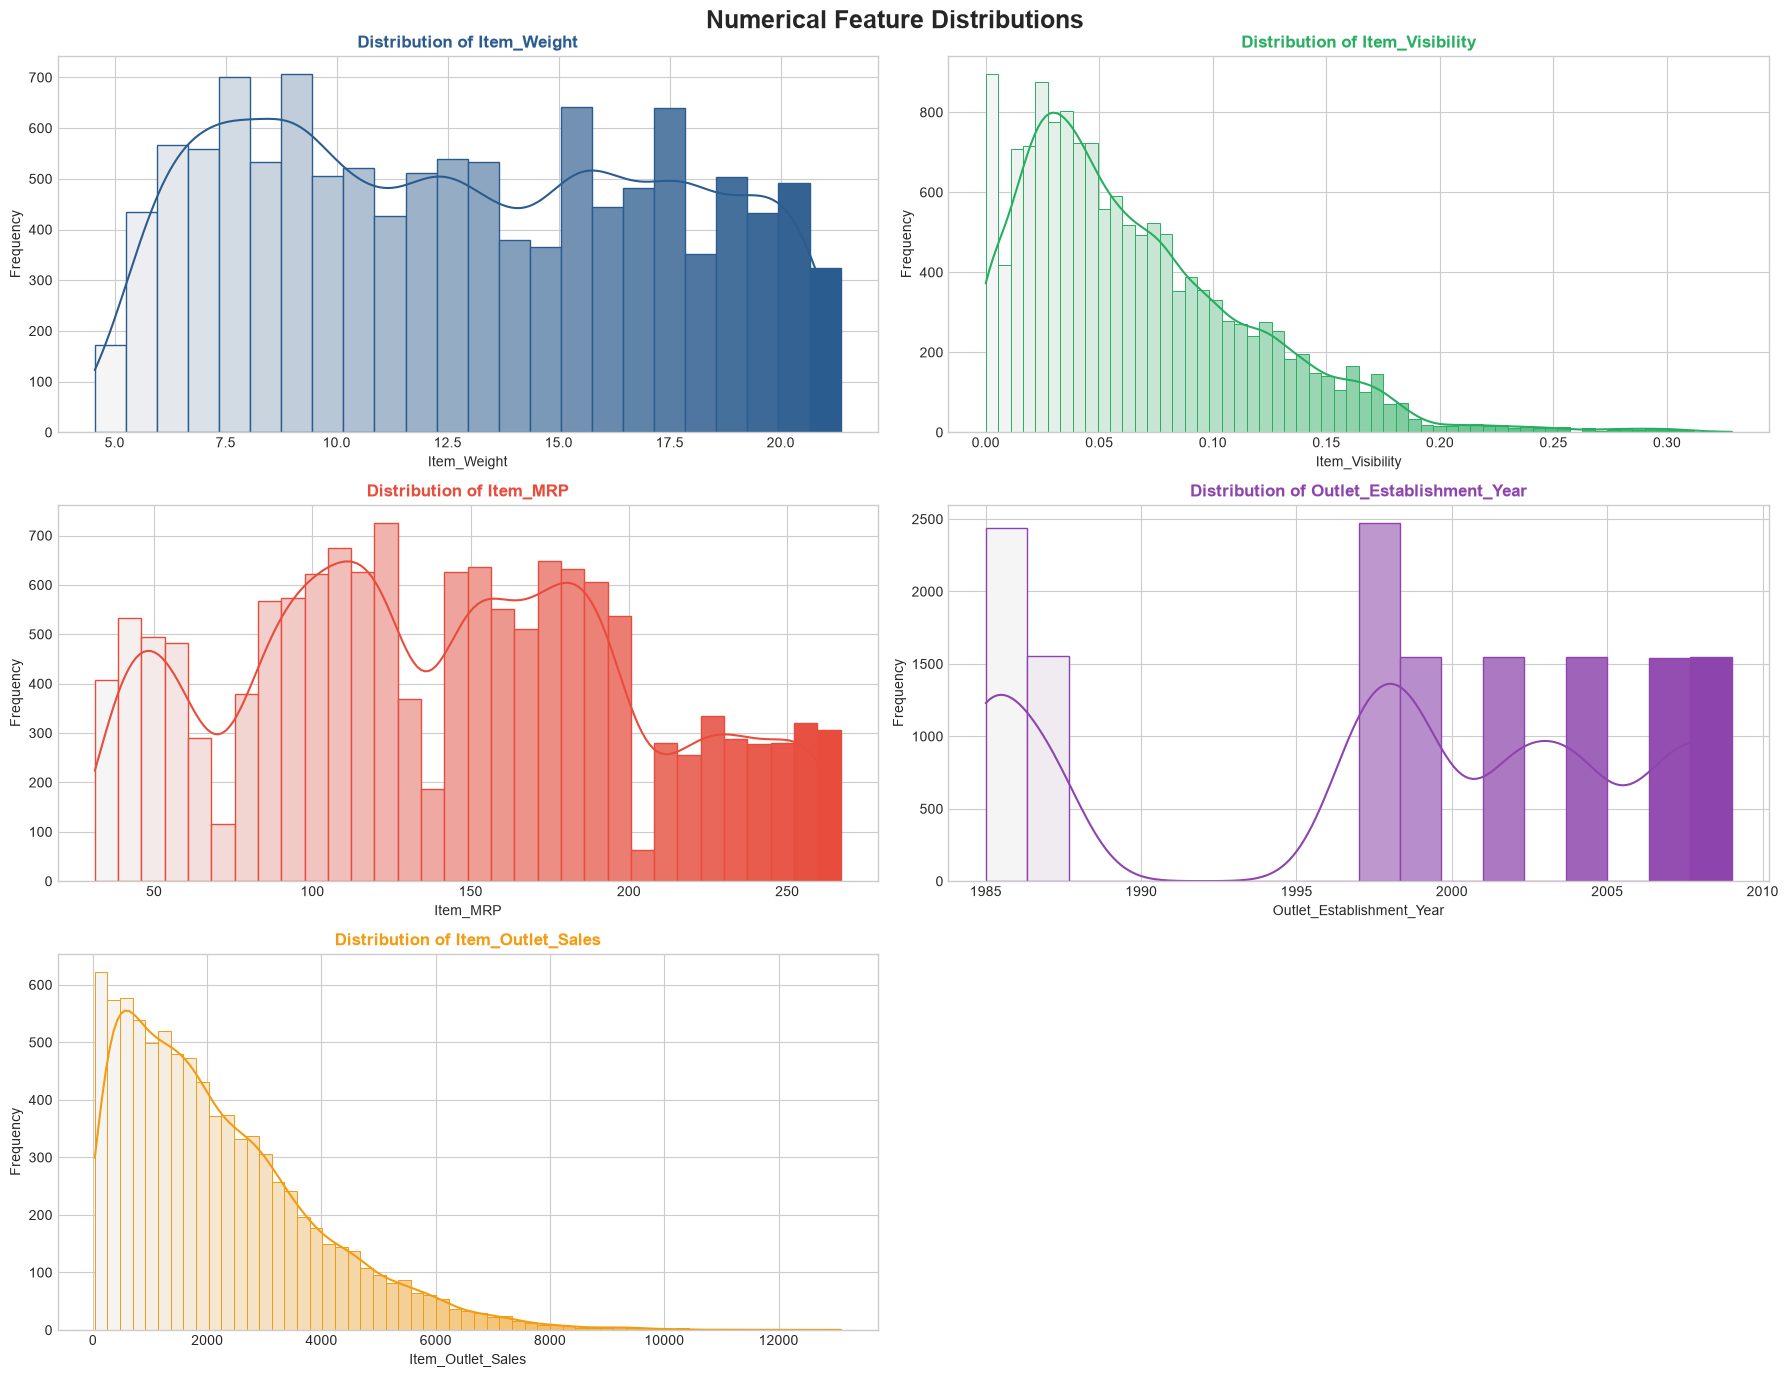

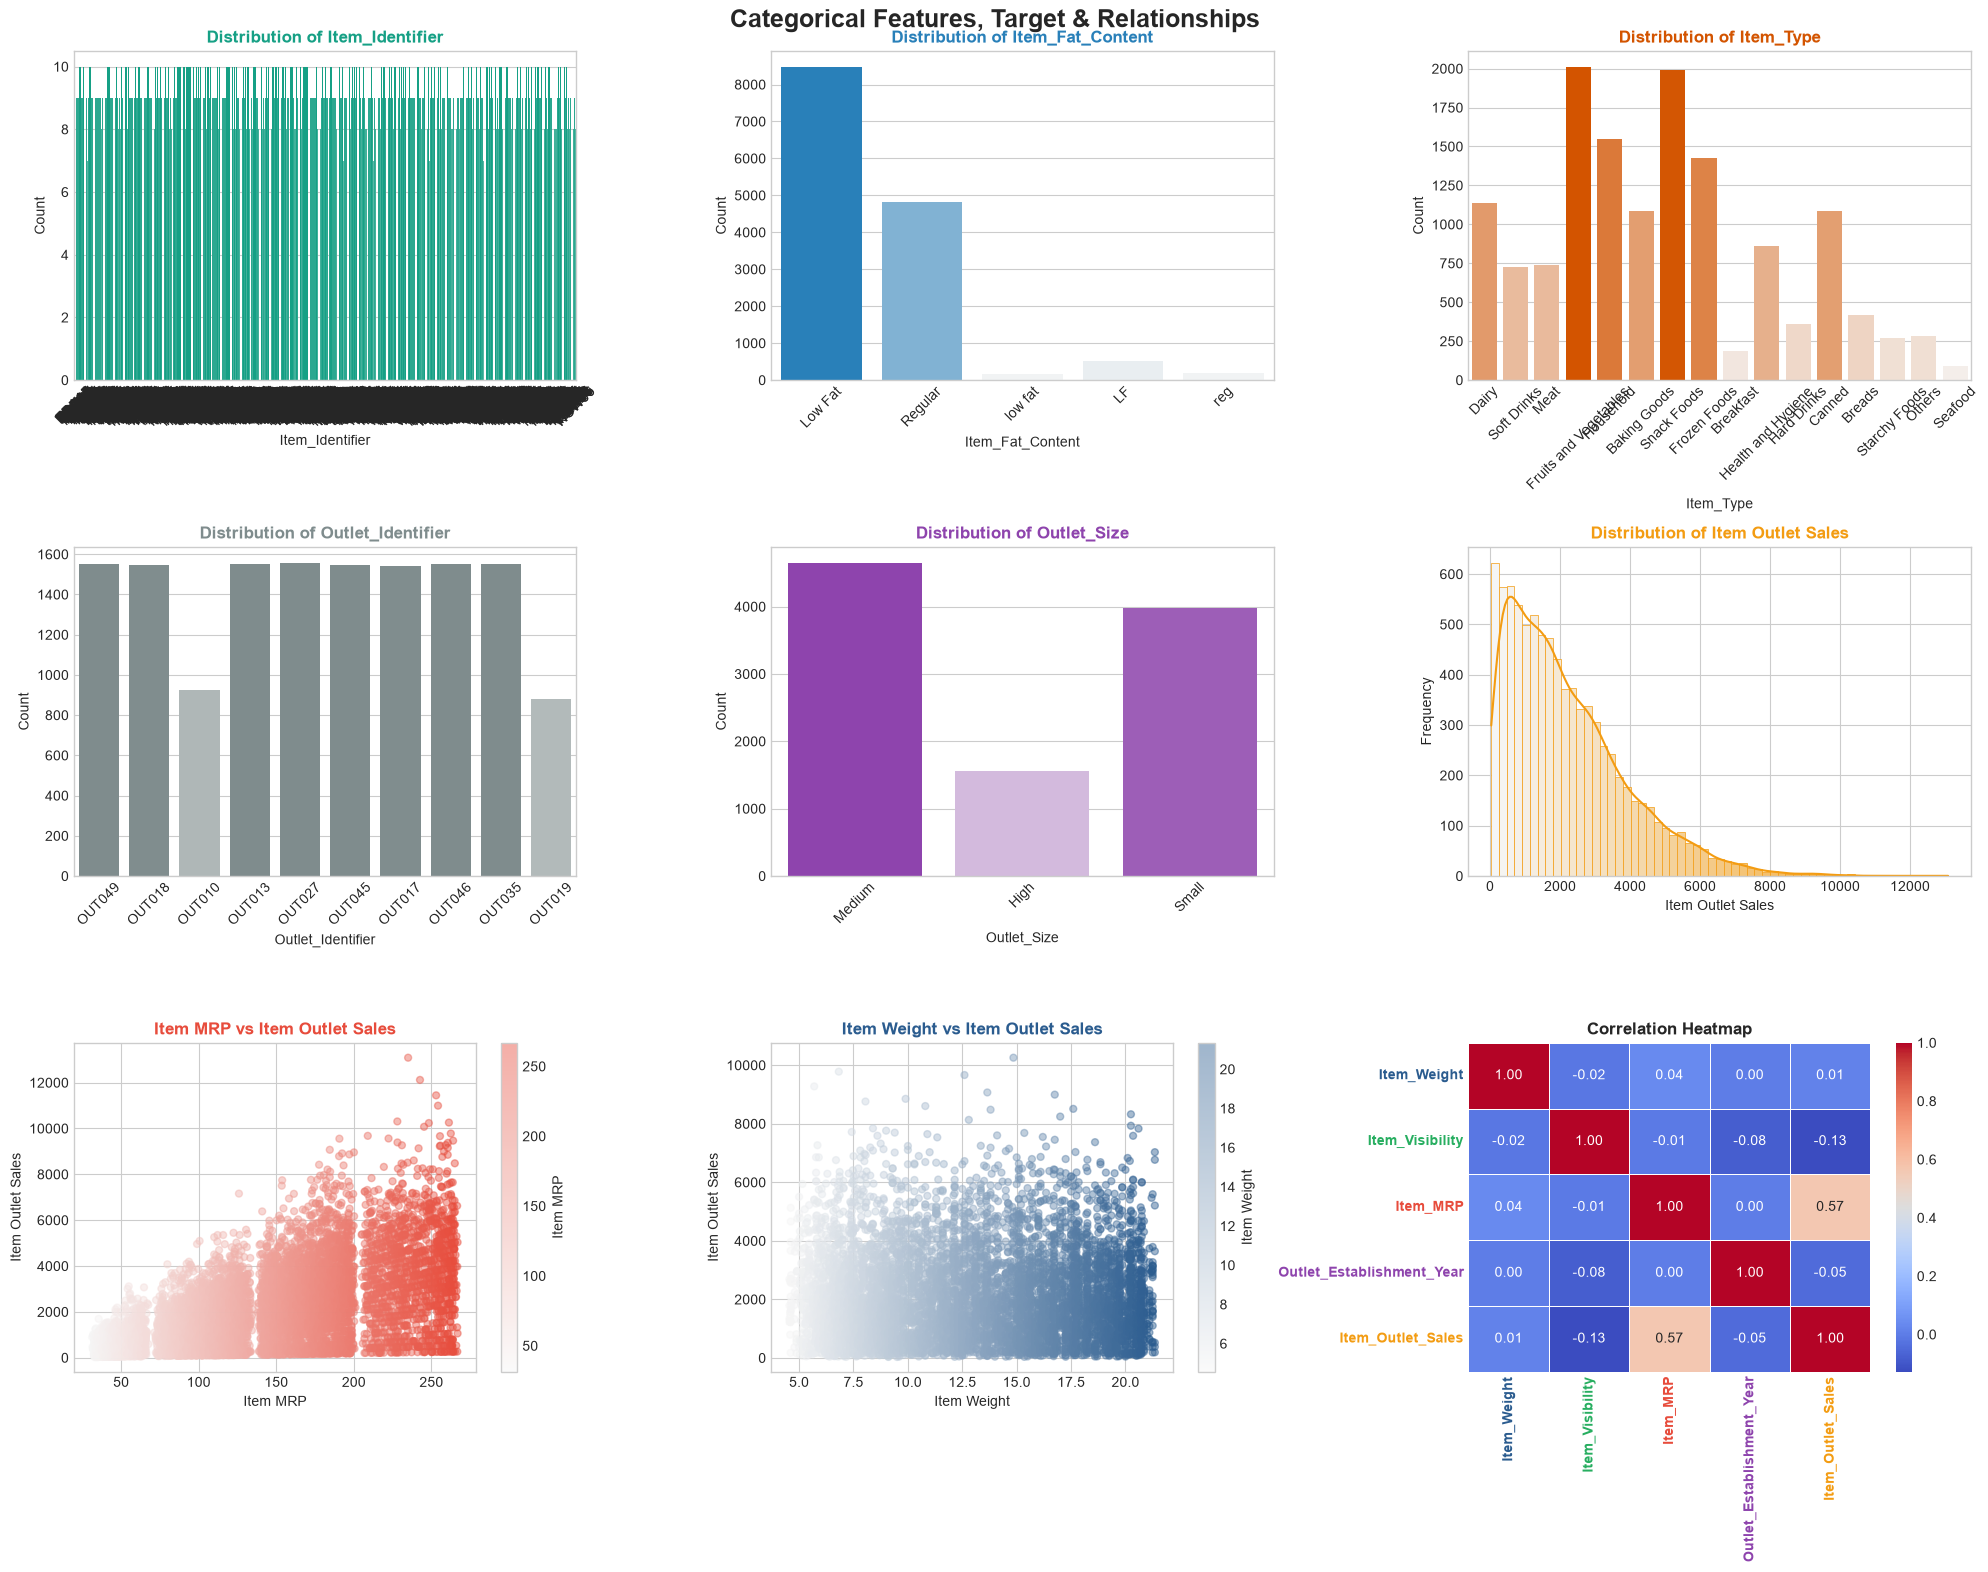

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


data_path = r'data/regression/data.csv'
df = pd.read_csv(data_path)


print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values Count:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nNumerical Features Summary:")
print(df.describe())

print("\nCategorical Features Summary:")
print(df.describe(include='object'))

print("\nTarget Distribution Summary ('Item_Outlet_Sales'):")
print(df['Item_Outlet_Sales'].describe())


numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns


# ============================================================
# FEATURE COLOUR GRADIENTS
# ============================================================

# Each feature gets its own colour family
feature_colors = {
    'Item_Weight': '#2b5c8f',
    'Item_Visibility': '#27ae60',
    'Item_MRP': '#e74c3c',
    'Outlet_Establishment_Year': '#8e44ad',
    'Item_Outlet_Sales': '#f39c12',
    'Item_Identifier': '#16a085',
    'Item_Fat_Content': '#2980b9',
    'Item_Type': '#d35400',
    'Outlet_Identifier': '#7f8c8d',
    'Outlet_Size': '#8e44ad',
    'Outlet_Location_Type': '#c0392b',
    'Outlet_Type': '#2c3e50'
}


# Function to create a light → dark gradient
def create_gradient(base_color):
    return LinearSegmentedColormap.from_list('feature_gradient', ['#f5f5f5', base_color], N=256)


# ============================================================
# FIGURE 1: NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

n_num = len(numerical_features)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()


for i, feature in enumerate(numerical_features):

    ax = axes[i]

    # Plot histogram first
    sns.histplot(df[feature].dropna(), kde=True, ax=ax, color=feature_colors.get(feature, '#2b5c8f'), alpha=0.75)

    # Create gradient across histogram bars
    cmap = create_gradient(feature_colors.get(feature, '#2b5c8f'))

    bars = ax.patches

    if len(bars) > 0:

        values = [bar.get_x() + bar.get_width() / 2 for bar in bars]

        min_value = min(values)
        max_value = max(values)

        for bar, value in zip(bars, values):

            if max_value != min_value:
                normalized = (value - min_value) / (max_value - min_value)
            else:
                normalized = 0.5

            bar.set_facecolor(cmap(normalized))
            bar.set_edgecolor(feature_colors.get(feature, '#2b5c8f'))

    ax.set_title(f'Distribution of {feature}', color=feature_colors.get(feature, '#2b5c8f'), fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')


# Hide unused subplots
for i in range(n_num, len(axes)):
    axes[i].axis('off')


plt.suptitle('Numerical Feature Distributions', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2: CATEGORICAL FEATURES + TARGET + RELATIONSHIPS
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()


# ============================================================
# CATEGORICAL DISTRIBUTIONS
# ============================================================

for i, feature in enumerate(categorical_features[:5]):

    ax = axes[i]

    # Countplot
    sns.countplot(data=df, x=feature, ax=ax, color=feature_colors.get(feature, '#2b5c8f'))

    # Apply gradient to bars
    cmap = create_gradient(feature_colors.get(feature, '#2b5c8f'))

    bars = ax.patches

    if len(bars) > 0:

        max_height = max(bar.get_height() for bar in bars)

        for bar in bars:

            height = bar.get_height()

            if max_height != 0:
                normalized = height / max_height
            else:
                normalized = 0.5

            bar.set_facecolor(cmap(normalized))

    ax.set_title(f'Distribution of {feature}', color=feature_colors.get(feature, '#2b5c8f'), fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)


# ============================================================
# TARGET DISTRIBUTION
# ============================================================

ax = axes[5]

sns.histplot(df['Item_Outlet_Sales'].dropna(), kde=True, ax=ax, color=feature_colors['Item_Outlet_Sales'], alpha=0.75)

# Gradient for target histogram
cmap = create_gradient(feature_colors['Item_Outlet_Sales'])

bars = ax.patches

if len(bars) > 0:

    values = [bar.get_x() + bar.get_width() / 2 for bar in bars]

    min_value = min(values)
    max_value = max(values)

    for bar, value in zip(bars, values):

        if max_value != min_value:
            normalized = (value - min_value) / (max_value - min_value)
        else:
            normalized = 0.5

        bar.set_facecolor(cmap(normalized))
        bar.set_edgecolor(feature_colors['Item_Outlet_Sales'])


ax.set_title('Distribution of Item Outlet Sales', color=feature_colors['Item_Outlet_Sales'], fontweight='bold')
ax.set_xlabel('Item Outlet Sales')
ax.set_ylabel('Frequency')


# ============================================================
# ITEM MRP VS SALES
# ============================================================

ax = axes[6]

scatter_data = df[['Item_MRP', 'Item_Outlet_Sales']].dropna()

scatter = ax.scatter(scatter_data['Item_MRP'], scatter_data['Item_Outlet_Sales'], c=scatter_data['Item_MRP'], cmap=create_gradient(feature_colors['Item_MRP']), alpha=0.45, s=25)

ax.set_title('Item MRP vs Item Outlet Sales', color=feature_colors['Item_MRP'], fontweight='bold')
ax.set_xlabel('Item MRP')
ax.set_ylabel('Item Outlet Sales')

# Gradient legend
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Item MRP')


# ============================================================
# ITEM WEIGHT VS SALES
# ============================================================

ax = axes[7]

scatter_data = df[['Item_Weight', 'Item_Outlet_Sales']].dropna()

scatter = ax.scatter(scatter_data['Item_Weight'], scatter_data['Item_Outlet_Sales'], c=scatter_data['Item_Weight'], cmap=create_gradient(feature_colors['Item_Weight']), alpha=0.45, s=25)

ax.set_title('Item Weight vs Item Outlet Sales', color=feature_colors['Item_Weight'], fontweight='bold')
ax.set_xlabel('Item Weight')
ax.set_ylabel('Item Outlet Sales')

# Gradient legend
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Item Weight')


# ============================================================
# CORRELATION HEATMAP
# ============================================================

ax = axes[8]

correlation_matrix = df[numerical_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)

ax.set_title('Correlation Heatmap', fontweight='bold')


# Colour-code heatmap labels
for label in ax.get_xticklabels():

    feature = label.get_text()

    if feature in feature_colors:

        label.set_color(feature_colors[feature])
        label.set_fontweight('bold')


for label in ax.get_yticklabels():

    feature = label.get_text()

    if feature in feature_colors:

        label.set_color(feature_colors[feature])
        label.set_fontweight('bold')


plt.suptitle('Categorical Features, Target & Relationships', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing


In [4]:
# 1. Clean & Standardize Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})

# 2. Impute Missing Values
df['Item_Weight'] = df.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

outlet_size_mode = df.groupby('Outlet_Type')['Outlet_Size'].apply(lambda x: x.mode()[0] if not x.mode().empty else 'Medium').to_dict()
df['Outlet_Size'] = df.apply(lambda x: outlet_size_mode[x['Outlet_Type']] if pd.isna(x['Outlet_Size']) else x['Outlet_Size'], axis=1)

item_visibility_mean = df.groupby('Item_Identifier')['Item_Visibility'].mean()
df['Item_Visibility'] = df.apply(lambda x: item_visibility_mean[x['Item_Identifier']] if x['Item_Visibility'] == 0 else x['Item_Visibility'], axis=1)

# 3. Feature Engineering: Item_Category and Outlet_Age
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])
df.loc[df['Item_Category'] == 'NC', 'Item_Fat_Content'] = 'Non-Edible'
df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# 4. Separate Train and Test subsets
train_df = df[df['source'] == 'train'].copy()
test_df = df[df['source'] == 'test'].copy()

drop_cols = ['Item_Identifier', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'source']
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols + ['Item_Outlet_Sales'], inplace=True)

# 5. Ordinal Encoding
outlet_size_map = {'Small': 0, 'Medium': 1, 'High': 2}
outlet_location_map = {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}

train_df['Outlet_Size'] = train_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
train_df['Outlet_Location_Type'] = train_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)
test_df['Outlet_Size'] = test_df['Outlet_Size'].map(outlet_size_map).fillna(1).astype(int)
test_df['Outlet_Location_Type'] = test_df['Outlet_Location_Type'].map(outlet_location_map).fillna(1).astype(int)

# 6. One-Hot Encoding for Nominal Features
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Type', 'Item_Category']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

train_cols = train_df.columns.drop('Item_Outlet_Sales')
for col in train_cols:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[train_cols]

# 7. Feature Engineering
# Feature A: Price_per_Weight (Item_MRP / Item_Weight)
train_df['Price_per_Weight'] = train_df['Item_MRP'] / train_df['Item_Weight']
test_df['Price_per_Weight'] = test_df['Item_MRP'] / test_df['Item_Weight']

# Feature B: Outlet_Age_Size (Outlet_Age * Outlet_Size)
outlet_size_num_map = {'Small': 1, 'Medium': 2, 'High': 3}
train_df['Outlet_Size_Num'] = train_df['Outlet_Size'].map({0: 1, 1: 2, 2: 3})
test_df['Outlet_Size_Num'] = test_df['Outlet_Size'].map({0: 1, 1: 2, 2: 3})
train_df['Outlet_Age_Size'] = train_df['Outlet_Age'] * train_df['Outlet_Size_Num']
test_df['Outlet_Age_Size'] = test_df['Outlet_Age'] * test_df['Outlet_Size_Num']
train_df.drop(columns=['Outlet_Size_Num'], inplace=True)
test_df.drop(columns=['Outlet_Size_Num'], inplace=True)

# Define Features and Target
X = train_df.drop('Item_Outlet_Sales', axis=1)
y = train_df['Item_Outlet_Sales']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_df)

# Global results list to store metric evaluation for all 10 algorithms
results_list = []

print("Preprocessing complete!")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_val shape: {X_val_scaled.shape}")

Preprocessing complete!
X_train shape: (6818, 30)
X_val shape: (1705, 30)


## 4. Model initialization, Training, Predicting


In [5]:
decision_tree = DecisionTreeRegressor(max_depth=5, min_samples_split=2, min_samples_leaf=5, random_state=42)

decision_tree.fit(X_train_scaled, y_train)

predicted_sales = decision_tree.predict(X_val_scaled)



## 5. Evaluation metrics of the model


In [6]:
r2_score_dt = r2_score(y_val, predicted_sales)
rmse_dt = np.sqrt(mean_squared_error(y_val, predicted_sales))
mae_dt = mean_absolute_error(y_val, predicted_sales)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(decision_tree, X_train_scaled, y_train, cv=kf, scoring='r2')

average_cv_r2 = np.mean(cv_scores)
std_cv_r2 = np.std(cv_scores)

results_list.append({
    'Algorithm': 'Decision Tree Regressor',
    'R2 Score': r2_score_dt,
    'RMSE': rmse_dt,
    'MAE': mae_dt,
    '5-Fold CV R2': average_cv_r2,
    '5-Fold CV Std': std_cv_r2
})

print("=" * 60)
print(" DECISION TREE REGRESSOR PERFORMANCE METRICS ")
print("=" * 60)
print(f"Validation R² Score     : {r2_score_dt:.4f}")
print(f"Validation RMSE         : {rmse_dt:.4f}")
print(f"Validation MAE          : {mae_dt:.4f}")
print(f"5-Fold CV R² Mean Score : {average_cv_r2:.4f} (+/- {std_cv_r2:.4f})")
print("=" * 60)


feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': decision_tree.feature_importances_}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance.head(5).to_string(index=False))




 DECISION TREE REGRESSOR PERFORMANCE METRICS 
Validation R² Score     : 0.6013
Validation RMSE         : 1040.9308
Validation MAE          : 725.2348
5-Fold CV R² Mean Score : 0.5820 (+/- 0.0171)

Top 5 Important Features:
                      Feature  Importance
                     Item_MRP    0.545511
Outlet_Type_Supermarket Type3    0.179832
Outlet_Type_Supermarket Type1    0.160414
                   Outlet_Age    0.092371
              Outlet_Age_Size    0.017728


## 6. Graphs


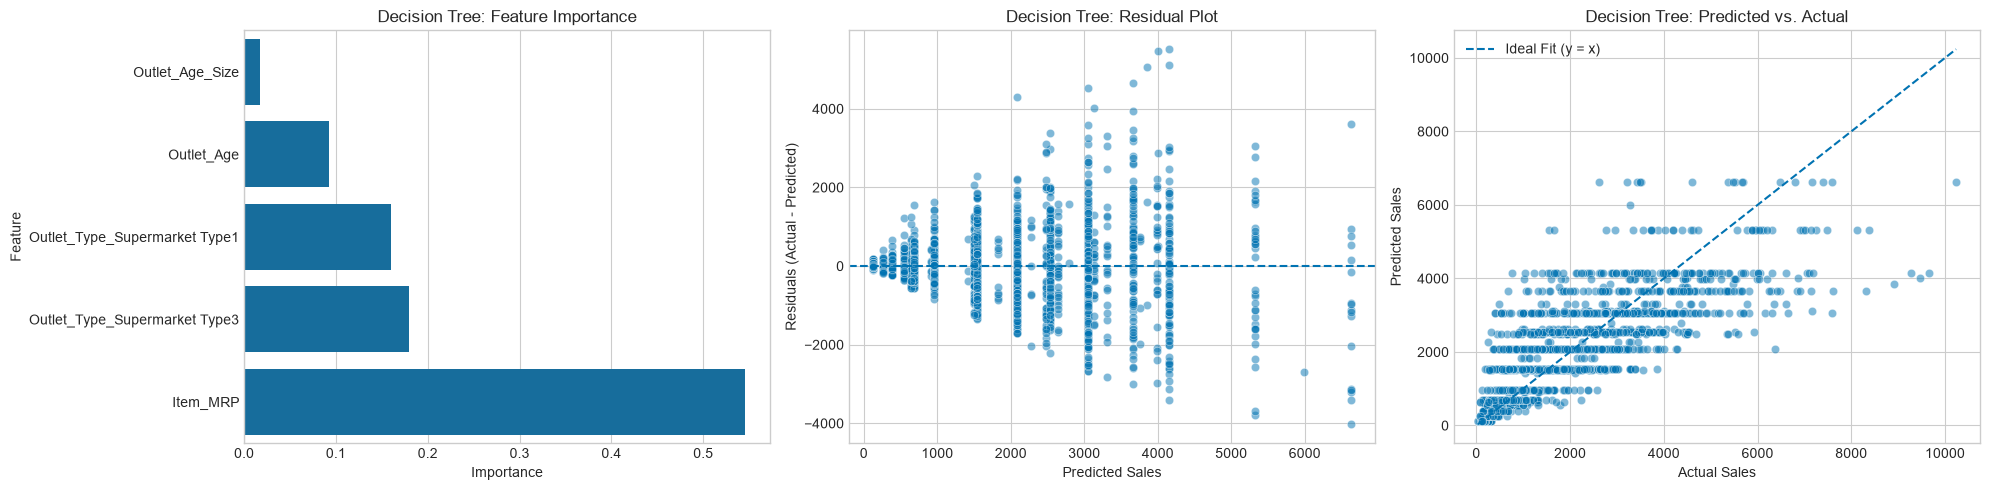

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

top_features = feature_importance.head(5).sort_values(by='Importance')

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    ax=axes[0]
)

axes[0].set_title('Decision Tree: Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')


residuals = y_val - predicted_sales

sns.scatterplot(
    x=predicted_sales,
    y=residuals,
    alpha=0.5,
    ax=axes[1]
)

axes[1].axhline(0, linestyle='--')
axes[1].set_title('Decision Tree: Residual Plot')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals (Actual - Predicted)')


sns.scatterplot(
    x=y_val,
    y=predicted_sales,
    alpha=0.5,
    ax=axes[2]
)

minimum = min(y_val.min(), predicted_sales.min())
maximum = max(y_val.max(), predicted_sales.max())

axes[2].plot(
    [minimum, maximum],
    [minimum, maximum],
    '--',
    linewidth=1.5,
    label='Ideal Fit (y = x)'
)

axes[2].set_title('Decision Tree: Predicted vs. Actual')
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].legend()

plt.tight_layout()
plt.show()